# 1. Charger les images avec image_dataset_from_directory. 

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Chargement
train_ds = tf.keras.utils.image_dataset_from_directory(
    "Data/train/",
    image_size       = (224, 224),
    batch_size       = 32,
    validation_split = 0.2,
    subset           = "training",
    seed             = 42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Data/test/",
    image_size       = (224, 224),
    batch_size       = 32,
    validation_split = 0.2,
    subset           = "validation",
    seed             = 42
)

# Vérification rapide
print(train_ds.class_names) 

for images, labels in train_ds.take(1):
    print(images.shape)  
    print(labels.shape) 
    


Found 20002 files belonging to 2 classes.
Using 16002 files for training.
Found 5000 files belonging to 2 classes.
Using 1000 files for validation.
['cats', 'dogs']
(32, 224, 224, 3)
(32,)


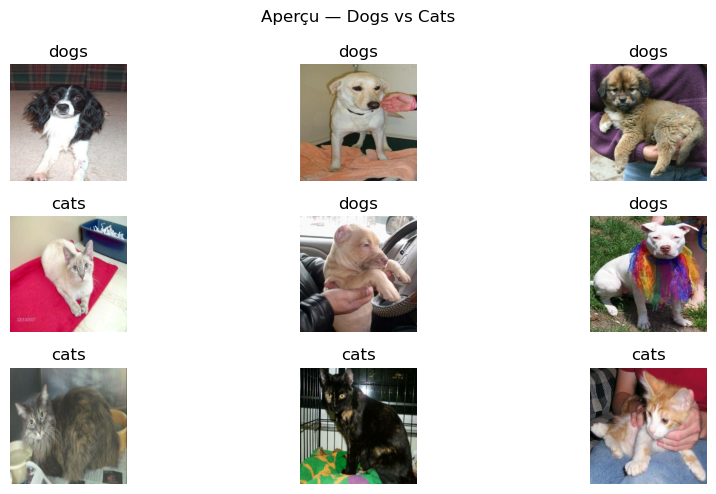

In [ ]:
# Aperçu du data set
class_names = train_ds.class_names

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 5))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    plt.suptitle("Aperçu — Dogs vs Cats")
    plt.tight_layout()
    plt.show()

# 2-Creation du CNN

In [ ]:
from tensorflow.keras.models import Sequential # importation de larchitectur qui permet que les couches s'empiles les unes sur les autres
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Dropout # importtion des differrente couches du CNN


model= Sequential([
    Rescaling(1./255,
              input_shape=(224,224,3)), #permet de ramener les pixels entre 0 et 1
    Conv2D(32, (3,3), activation='relu'), #premier convolution avec 32 filtres
    MaxPooling2D((2,2)), #premier pooling
    Conv2D(64, (3,3), activation='relu'), #deuxieme couche de convolution avec 64 filtres
    MaxPooling2D((2,2)), #deuxieme pooling
    Conv2D(128, (3,3), activation='relu'), # troisime couche de convoltion avec 124 filtres
    MaxPooling2D((2,2)),
    Flatten(), #permet de convertir la matrice en vecteur
    Dense(128, activation='relu'), # 128 neurones combines les caracterisques extrait par les conv
    Dropout(0.5),# couche qui ddesactive 50% des neuronnes pendant lentrainement a chaque iteration
    Dense(1, activation= 'sigmoid')# couche de sorti avec une activation sigmoide car nous sommes dans une classifiction binaire
    
])

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compilation du modele

In [ ]:
model.compile(
    optimizer='adam', # choisit l;algorithme qui mettra a jour les poids du reseaux
    loss='binary_crossentropy', # mesure l'erreur entre les predeictions du  odeles et les vraies etiquettes pour deux classe
    metrics= ['accuracy'] #demandes a tensorflow dafficher le pourcentages de predictions correctes
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 6110s 12s/step - accuracy: 0.5991 - loss: 0.6662 - val_accuracy: 0.7130 - val_loss: 0.5691
Epoch 2/10
251/501 ━━━━━━━━━━━━━━━━━━━━ 22:20 5s/step - accuracy: 0.7044 - loss: 0.5816